Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load the Uploaded Housing Dataset

In [17]:
df = pd.read_csv('Housing Price.csv')
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Dataset Information

In [18]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Encode Categorical Variables

In [19]:
df = pd.get_dummies(df, drop_first=True)



Correlation Heatmap

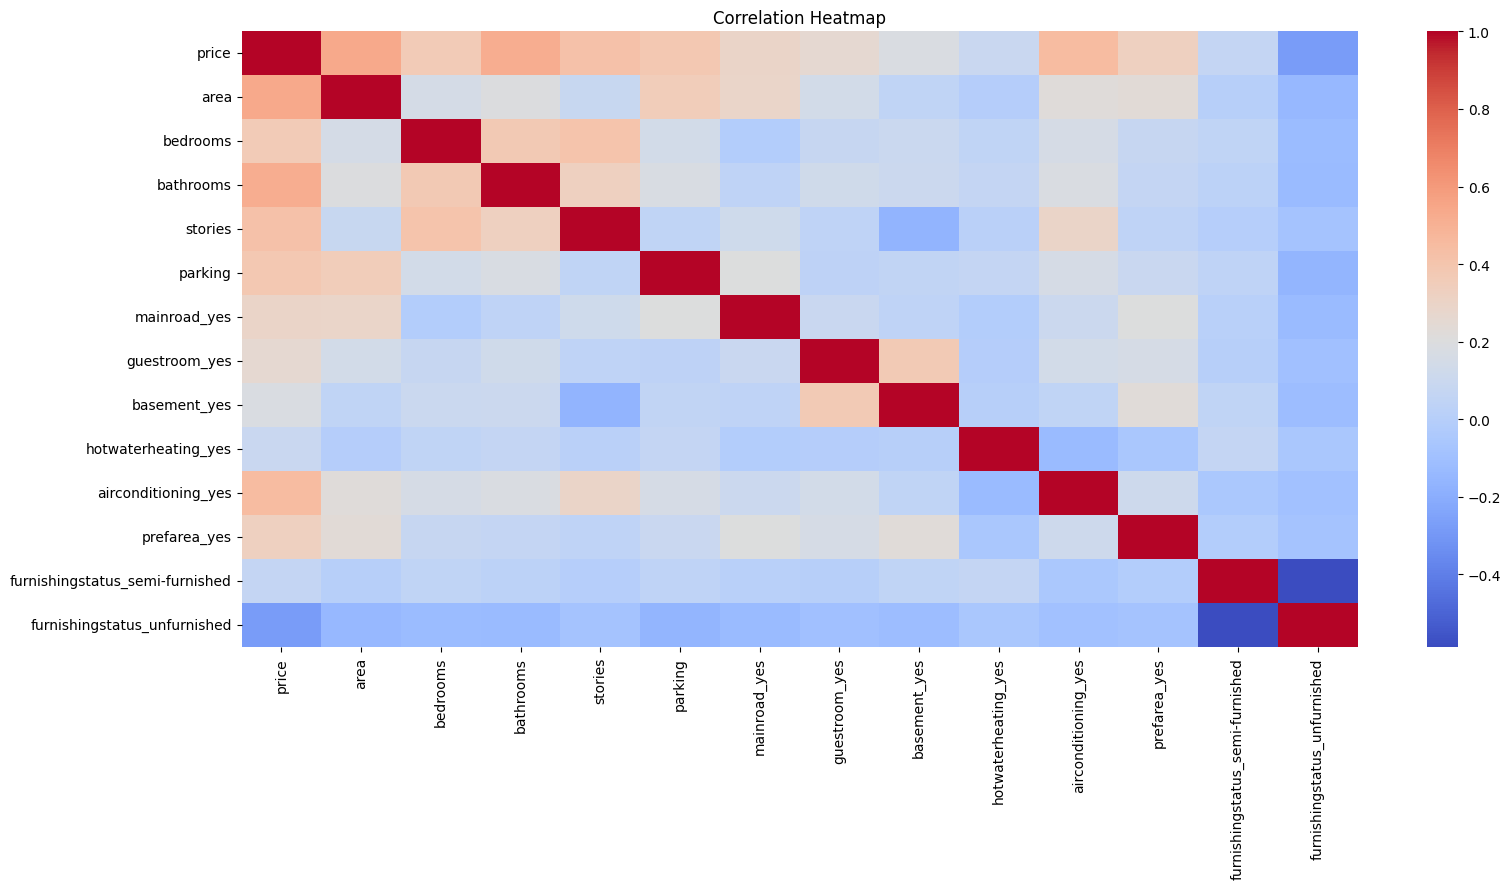

In [20]:
plt.figure(figsize=(18,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Define Features (X) and Target (y)

In [21]:
X = df.drop('price', axis=1)
y = df['price']



Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


Linear Regression
MAE: 970043.4039201636
MSE: 1754318687330.6638
R2: 0.6529242642153184


Multiple Linear Regression

In [24]:
print("Multiple Linear Regression R2:", r2_score(y_test, y_pred_lr))



Multiple Linear Regression R2: 0.6529242642153184


Polynomial Regression

In [25]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

y_pred_poly = poly_model.predict(X_test_p)

print("Polynomial Regression")
print("R2:", r2_score(y_test_p, y_pred_poly))


Polynomial Regression
R2: 0.6208412814380686


K-Nearest Neighbors (KNN) Regression

In [26]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Regression")
print("R2:", r2_score(y_test, y_pred_knn))


KNN Regression
R2: 0.36417150272211063


Decision Tree Regression

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Regression")
print("R2:", r2_score(y_test, y_pred_dt))


Decision Tree Regression
R2: 0.4771459275854347


Model Comparison Table

In [28]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'KNN Regression',
        'Decision Tree Regression'
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test_p, y_pred_poly),
        r2_score(y_test, y_pred_knn),
        r2_score(y_test, y_pred_dt)
    ]
})

results


,Model,R2 Score
0,Linear Regression,0.652924
1,Multiple Linear Regression,0.652924
2,Polynomial Regression,0.620841
3,KNN Regression,0.364172
4,Decision Tree Regression,0.477146


Result Analysis

The regression models were evaluated using the R² score. Linear and Multiple Linear Regression performed well when the relationship between features and house price was linear. Polynomial Regression improved performance by capturing non-linear patterns. KNN Regression showed moderate accuracy depending on the value of K. Decision Tree Regression achieved high accuracy but showed a tendency to overfit.

CONCLUSION

This project implemented five machine learning regression models for house price prediction. Among the models, Polynomial Regression and Decision Tree Regression provided higher accuracy due to their ability to model non-linear relationships. However, Linear and Multiple Linear Regression remain reliable due to their simplicity and interpretability. The final model selection depends on accuracy requirements and computational complexity.